### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from EA import EvolutionaryAlgorithm

In [2]:
def test_function(x):
    return x[0]**2 + x[1]**2 + 2 * x[2]**2

def rastrigin_function(x):
    A = 10
    return A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x))

### Ewaluacja na dwóch funkcjach

##### test_function

In [3]:
ea = EvolutionaryAlgorithm(
    objective_function=test_function, 
    dimensions=3,
    bounds=(-10, 10), 
    population_size=100, 
    generations=1_000,
    crossover_rate=0.8, mutation_rate=0.2, sigma=0.5, tournament_size=5
)

In [4]:
best_vector, best_value, history = ea.run()

print("Found vector (optimum):", best_vector)
print("Function value at this point:", best_value)

Found vector (optimum): [-3.45395262e-09  3.82314845e-10  1.40665071e-17]
Function value at this point: 1.207595335388686e-17


In [ ]:
plt.plot(range(1, len(history)+1), history)
plt.xlabel('Generation')
plt.ylabel('Best Function Value')
plt.yscale('log')
plt.title('Evolution of Best Function Value')
plt.grid()
plt.show()

In [69]:
ea = EvolutionaryAlgorithm(
    objective_function=rastrigin_function, 
    dimensions=5, 
    bounds=(-5.12, 5.12), 
    population_size=100, 
    generations=10_000,
    crossover_rate=0.8, mutation_rate=0.2, sigma=0.5, tournament_size=5
)

In [70]:
best_vector, best_value, history = ea.run()

print("Found vector (optimum):", best_vector)
print("Function value at this point:", best_value)

Found vector (optimum): [ 1.41866745e-09 -5.72748225e-09  2.04068940e-09 -2.77747542e-09
  3.73010216e-09]
Function value at this point: 7.105427357601002e-15


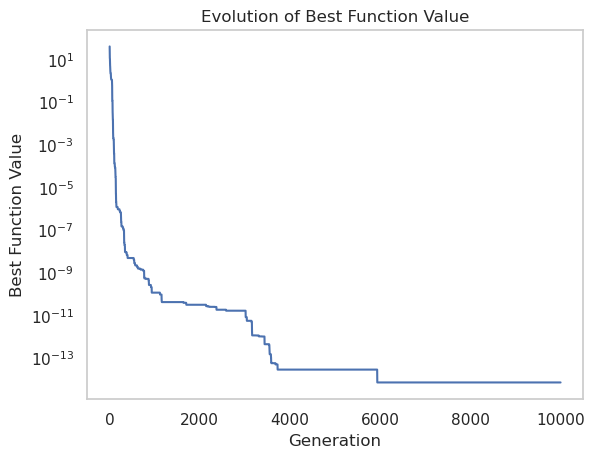

In [72]:
plt.plot(range(1, len(history)+1), history)
plt.xlabel('Generation')
plt.ylabel('Best Function Value')
plt.yscale('log')
plt.title('Evolution of Best Function Value')
plt.grid()
plt.show()

#### rastrigin_function

In [75]:
scores = []
for t_size in range(1, 50):
    temp_scores = []
    for _ in range(5):
        ea = EvolutionaryAlgorithm(
            objective_function=rastrigin_function, 
            dimensions=5, 
            bounds=(-5.12, 5.12), 
            population_size=100, 
            generations=100,
            crossover_rate=0.8, mutation_rate=0.2, sigma=0.5, tournament_size=t_size
            )
        _, best_value, _ = ea.run()
        temp_scores.append(best_value)
    
    scores.append(np.median(temp_scores))

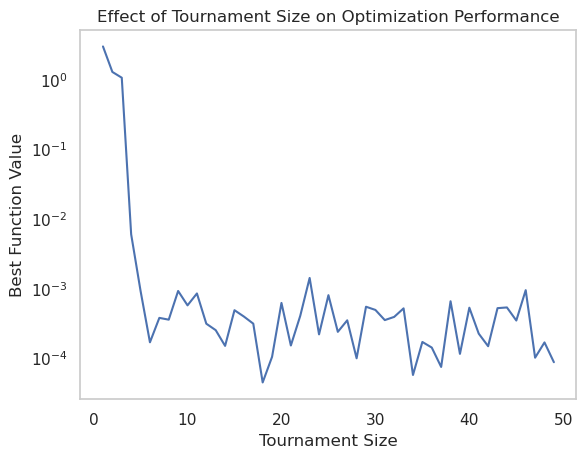

In [77]:
plt.plot(range(1, 50), scores)
plt.xlabel('Tournament Size')
plt.ylabel('Best Function Value')
plt.yscale('log')
plt.title('Effect of Tournament Size on Optimization Performance')
plt.grid()
plt.show()

### Grid search for best parameters

In [ ]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import display, HTML

def run_grid_search(generations=1000):
    crossover_rates = [0.5, 0.75, 1.0]
    mutation_rates = [0.05, 0.1, 0.2, 0.3, 0.5]
    sigmas = [0.05, 0.1, 0.5, 1.0]
    num_runs = 5
    
    param_combinations = list(itertools.product(crossover_rates, mutation_rates, sigmas))
    total_experiments = len(param_combinations) * num_runs
    
    results_list = []
    
    print(f"Starting Grid Search: {len(param_combinations)} combinations x {num_runs} runs.")
    print(f"Total algorithm executions: {total_experiments}")
    
    with tqdm(total=total_experiments, desc="Experiment Progress") as pbar:
        for cr, mr, sigma in param_combinations:
            for run_idx in range(num_runs):
                ea = EvolutionaryAlgorithm(
                    objective_function=rastrigin_function, 
                    dimensions=5, 
                    bounds=(-5.12, 5.12), 
                    population_size=100, 
                    generations=generations,
                    crossover_rate=cr, 
                    mutation_rate=mr, 
                    sigma=sigma, 
                    tournament_size=5
                )
                
                _, best_value, _ = ea.run()

                results_list.append({
                    'Crossover Rate': cr,
                    'Mutation Rate': mr,
                    'Sigma': sigma,
                    'Run': run_idx + 1,
                    'Best Score': best_value
                })
                
                pbar.update(1)
                
    return pd.DataFrame(results_list)

def analyze_and_plot(df):
    stats_df = df.groupby(['Crossover Rate', 'Mutation Rate', 'Sigma'])['Best Score'].agg(
        Mean='mean',
        Std='std',
        Best_Overall='min'
    ).reset_index()
    
    stats_df = stats_df.sort_values(by='Mean')
    
    print("\nAggregated Grid Search Results (Sorted by Best Mean):")
    display(stats_df.head(10))
    
    sns.set_theme(style="whitegrid")
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df, 
        x='Sigma', 
        y='Best Score', 
        hue='Mutation Rate',
        palette="viridis"
    )
    plt.title("Distribution of Best Scores by Sigma and Mutation Rate", fontsize=14, fontweight='bold')
    plt.yscale('log')
    plt.ylabel("Best Score (Log Scale)")
    plt.legend(title="Mutation Rate", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df, 
        x='Sigma', 
        y='Best Score', 
        hue='Crossover Rate',
        palette="viridis"
    )
    plt.title("Distribution of Best Scores by Sigma and Crossover Rate", fontsize=14, fontweight='bold')
    plt.yscale('log')
    plt.ylabel("Best Score (Log Scale)")
    plt.legend(title="Crossover Rate", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df, 
        x='Mutation Rate', 
        y='Best Score', 
        hue='Crossover Rate',
        palette="viridis"
    )
    plt.title("Distribution of Best Scores by Mutation Rate and Crossover Rate", fontsize=14, fontweight='bold')
    plt.yscale('log')
    plt.ylabel("Best Score (Log Scale)")
    plt.legend(title="Crossover Rate", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    heatmap_data = stats_df.groupby(['Mutation Rate', 'Sigma'])['Mean'].mean().unstack()
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Mean Best Score'})
    plt.title("Heatmap of Mean Best Scores\n(Averaged across Crossover Rates)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [61]:
results_dataframe = run_grid_search(generations=1000)

Starting Grid Search: 60 combinations x 5 runs.
Total algorithm executions: 300


Experiment Progress:   0%|          | 0/300 [00:00<?, ?it/s]


Aggregated Grid Search Results (Sorted by Best Mean):


,Crossover Rate,Mutation Rate,Sigma,Mean,Std,Best_Overall
30,0.75,0.20,0.5,1.909342e-10,1.506194e-10,2.160050e-11
10,0.50,0.20,0.5,3.352071e-10,5.928683e-10,8.526513e-13
31,0.75,0.20,1.0,9.192007e-10,1.038645e-09,2.614300e-10
11,0.50,0.20,1.0,1.505913e-09,1.850777e-09,5.869083e-12
50,1.00,0.20,0.5,7.032206e-09,5.166112e-09,1.121066e-09
51,1.00,0.20,1.0,1.960012e-07,2.649062e-07,1.190864e-08
46,1.00,0.10,0.5,2.933287e-07,5.769360e-07,3.195098e-10
6,0.50,0.10,0.5,1.473989e-06,2.259812e-06,3.250349e-09
42,1.00,0.05,0.5,1.572397e-06,3.139286e-06,1.352397e-08
7,0.50,0.10,1.0,2.180710e-06,3.171157e-06,1.167397e-07


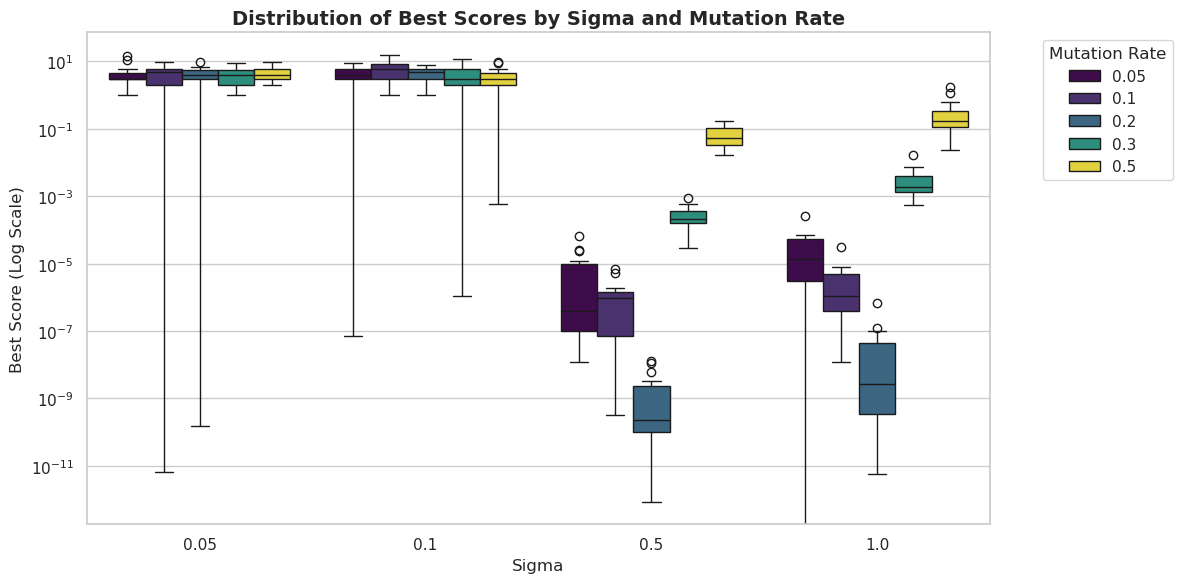

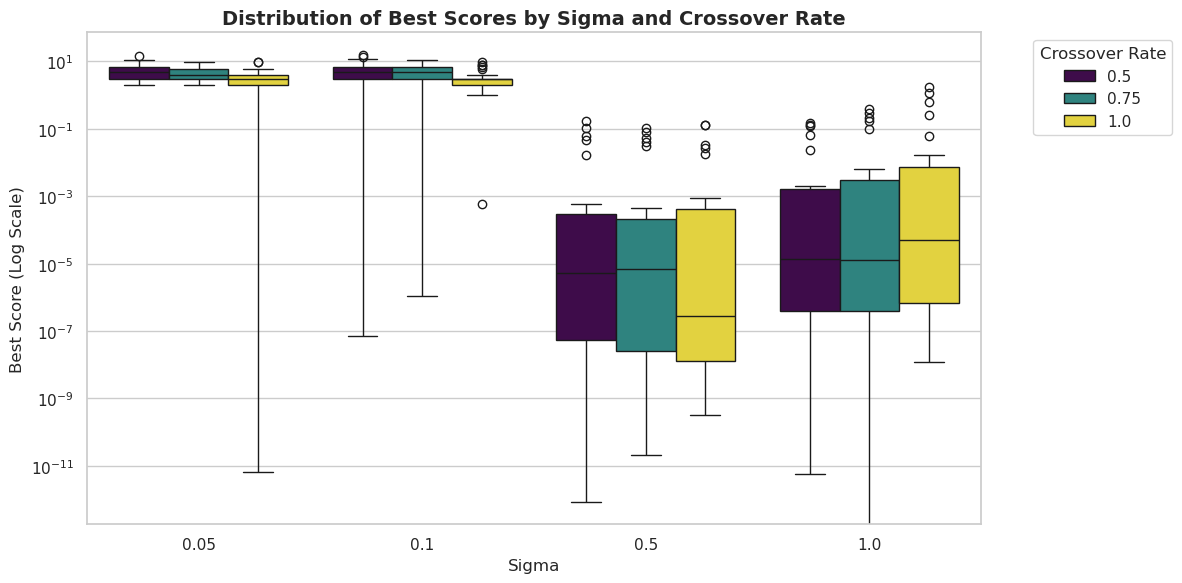

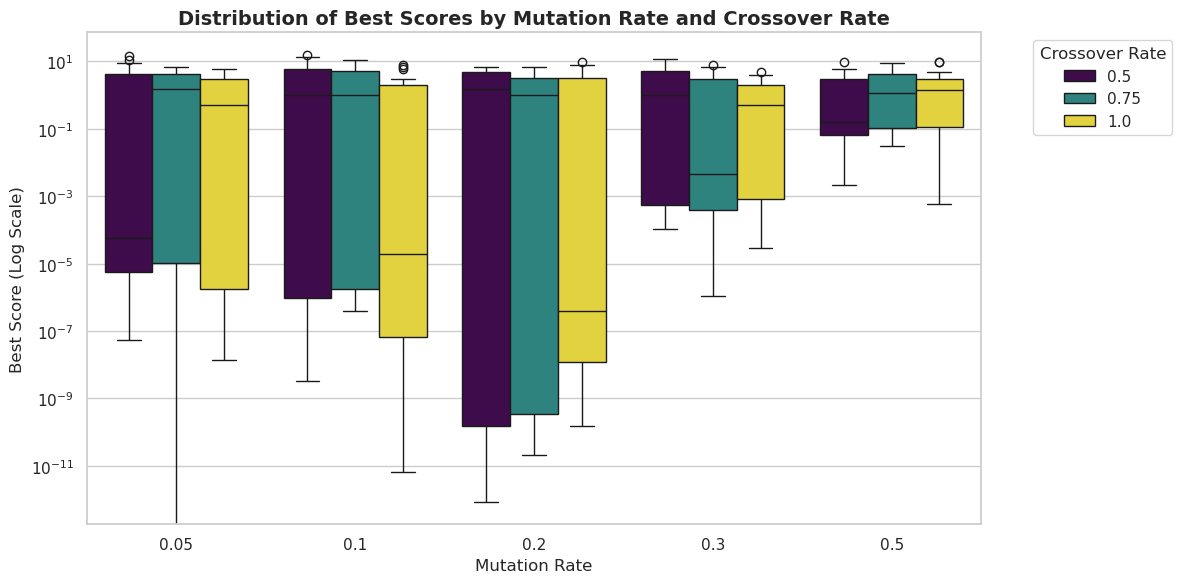

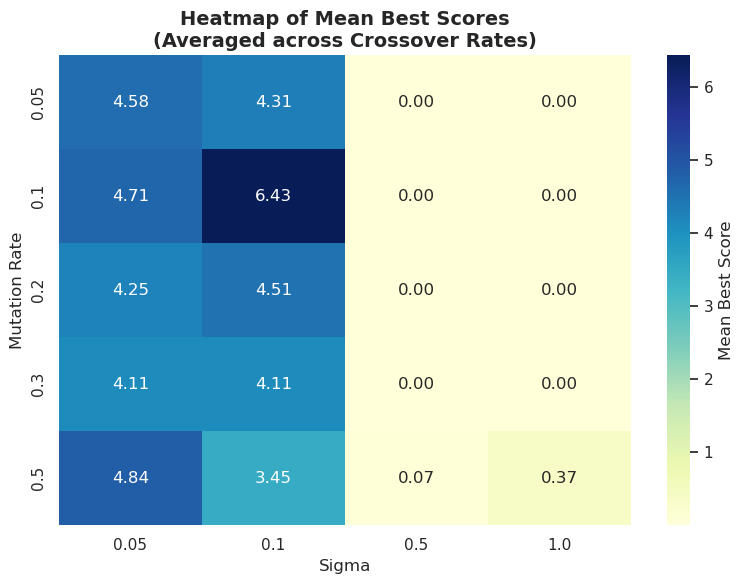

In [64]:
analyze_and_plot(results_dataframe)

Best params:

Mutation Rate 0.2

Crossover ? 0.5

Sigma 0.5